In [1]:
import duckdb
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from utils import (
    get_df,
    compare_dataframes,
    write_parquet
)

original_path = "./datasets_parquet/nhagar/fineweb_urls/nhagar_fineweb_urls.parquet"
compressed_path = "./datasets_compress/nhagar/fineweb_urls/nhagar_fineweb_urls.parquet"
original_size = os.path.getsize(original_path)
compressed_size = os.path.getsize(compressed_path)
con = duckdb.connect()

In [2]:
# Query timings
def time_query(sql, print_result=True):
    start = time.time()
    result = con.execute(sql).fetchdf()
    if print_result:
        print(result)
    return time.time() - start

# Register Parquet files as DuckDB views
con.execute(f"CREATE VIEW original AS SELECT * FROM parquet_scan('{original_path}')")
con.execute(f"CREATE VIEW virtual AS SELECT * FROM parquet_scan('{compressed_path}')")

In [3]:
t1 = time_query("SUMMARIZE SELECT url, domain FROM original")
t2 = time_query("SUMMARIZE SELECT url, SUBSTR(url, domain_offset + 1, domain_length) || CASE WHEN is_outlier THEN '.' ELSE '' END AS domain FROM virtual")
print(f"Original query time: {t1:.4f} seconds")
print(f"Compressed query time: {t2:.4f} seconds")

  column_name column_type                                                min  \
0         url     VARCHAR  http://0-blogs.biomedcentral.com.brum.beds.ac....   
1      domain     VARCHAR                                        000-967.com   

                                                 max  approx_unique   avg  \
0  https://zzzzteng.wordpress.com/2017/01/15/job-...        1226510  <NA>   
1                                 zzzworldninjas.com         309940  <NA>   

    std   q25   q50   q75    count  null_percentage  
0  <NA>  <NA>  <NA>  <NA>  1000000              0.0  
1  <NA>  <NA>  <NA>  <NA>  1000000              0.0  
  column_name column_type                                                min  \
0         url     VARCHAR  http://0-blogs.biomedcentral.com.brum.beds.ac....   
1      domain     VARCHAR                                        000-967.com   

                                                 max  approx_unique   avg  \
0  https://zzzzteng.wordpress.com/2017/01/15/jo

In [5]:
t3 = time_query("SUMMARIZE SELECT LENGTH(url), LENGTH(domain) FROM original")
t4 = time_query("SUMMARIZE SELECT LENGTH(url), LENGTH(SUBSTR(url, domain_offset + 1, domain_length) || CASE WHEN is_outlier THEN '.' ELSE '' END) AS 'length(\"domain\")' FROM virtual")
t5 = time_query("SUMMARIZE SELECT LENGTH(url), domain_length + CASE WHEN is_outlier THEN 1 ELSE 0 END AS 'length(\"domain\")' FROM virtual", )
print(f"Original query time: {t3:.4f} seconds")
print(f"Compressed query time: {t4:.4f} seconds")
print(f"Trick query time: {t5:.4f} seconds")

        column_name column_type min   max  approx_unique        avg  \
0       length(url)      BIGINT  14  1572            482  72.011063   
1  length("domain")      BIGINT   4    65             54  14.741602   

                  std q25 q50 q75    count  null_percentage  
0  27.689505978236067  52  68  87  1000000              0.0  
1   4.629860031275174  12  14  17  1000000              0.0  
        column_name column_type min   max  approx_unique        avg  \
0       length(url)      BIGINT  14  1572            482  72.011063   
1  length("domain")      BIGINT   4    65             54  14.741602   

                  std q25 q50 q75    count  null_percentage  
0  27.689505978236067  52  68  87  1000000              0.0  
1   4.629860031275174  12  14  17  1000000              0.0  
        column_name column_type min   max  approx_unique        avg  \
0       length(url)      BIGINT  14  1572            482  72.011063   
1  length("domain")      BIGINT   4    65             54  

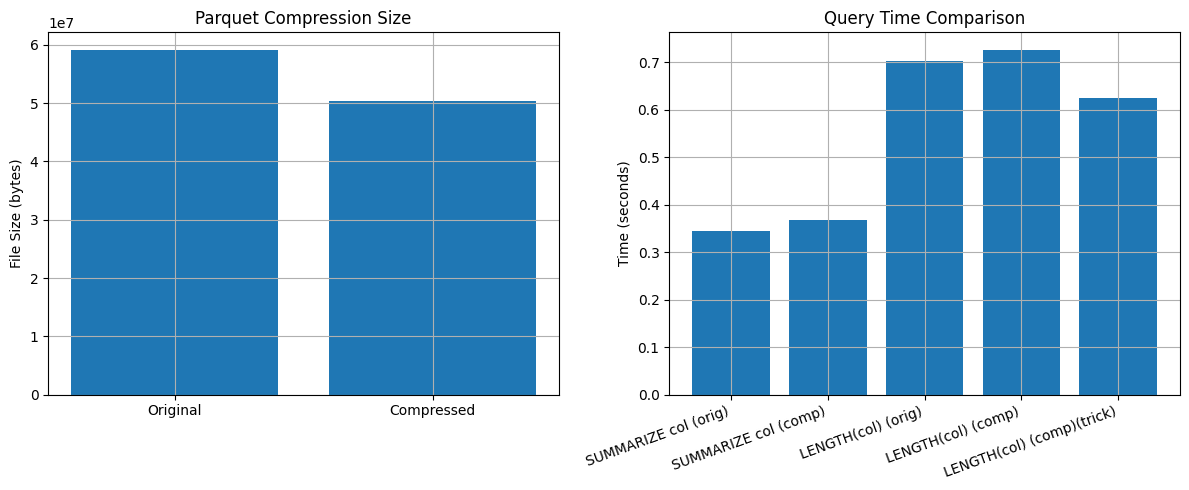

In [6]:
plt.figure(figsize=(12, 5))

# Left: File sizes
plt.subplot(1, 2, 1)
plt.bar(['Original', 'Compressed'], [original_size, compressed_size])
plt.ylabel('File Size (bytes)')
plt.title('Parquet Compression Size')
plt.grid(True)

# Right: Query times
labels = ["SUMMARIZE col (orig)", "SUMMARIZE col (comp)", "LENGTH(col) (orig)", "LENGTH(col) (comp)", "LENGTH(col) (comp)(trick)"]
times = [t1, t2, t3, t4, t5]
plt.subplot(1, 2, 2)
plt.bar(labels, times)
plt.ylabel('Time (seconds)')
plt.title('Query Time Comparison')
plt.xticks(rotation=20, ha='right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
compressed_size / original_size

0.8515934362461176